In [4]:
# Dataset Load :

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Heart.csv')
df = df.drop('Unnamed: 0', axis=1)
df = df.drop_duplicates()
df = df.dropna()

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:", df.isnull().sum())
df.head()

Shape: (297, 14)

Columns: ['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD']

Missing Values: Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           0
Thal         0
AHD          0
dtype: int64


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [5]:
# Data Types & Info :
print("Dataset Info:")
print(df.info())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB
None

Data Types:
Age            int64
Sex            int64
ChestPain     object
RestBP         int64
Chol           int64
Fbs            int64
RestECG        int64
MaxHR          int

In [6]:
# Meaningful Questions :
print("BUSINESS QUESTIONS:")
print("="*45)
print("Q1: What is the heart disease rate?")
print("Q2: Which age group is most affected?")
print("Q3: Is cholesterol linked to disease?")
print("Q4: Which chest pain type is dangerous?")
print("Q5: Gender wise disease distribution?")

# Q1: Heart disease rate
rate = df['AHD'].value_counts(normalize=True)*100
print("\nA1: Heart Disease Rate:")
print(rate)

# Q2: Age groups
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0,40,50,60,100],
                          labels=['<40','40-50','50-60','60+'])
print("\nA2: Age Group Distribution:")
print(df.groupby('Age_Group')['AHD'].value_counts())

# Q3: Cholesterol
print("\nA3: Average Cholesterol:")
print(df.groupby('AHD')['Chol'].mean())

# Q4: Chest Pain
print("\nA4: Chest Pain vs Disease:")
print(pd.crosstab(df['ChestPain'], df['AHD']))

# Q5: Gender
print("\nA5: Gender vs Disease:")
print(pd.crosstab(df['Sex'], df['AHD']))

BUSINESS QUESTIONS:
Q1: What is the heart disease rate?
Q2: Which age group is most affected?
Q3: Is cholesterol linked to disease?
Q4: Which chest pain type is dangerous?
Q5: Gender wise disease distribution?

A1: Heart Disease Rate:
AHD
No     53.872054
Yes    46.127946
Name: proportion, dtype: float64

A2: Age Group Distribution:
Age_Group  AHD
<40        No     11
           Yes     6
40-50      No     53
           Yes    22
50-60      Yes    65
           No     61
60+        Yes    44
           No     35
Name: count, dtype: int64

A3: Average Cholesterol:
AHD
No     243.493750
Yes    251.854015
Name: Chol, dtype: float64

A4: Chest Pain vs Disease:
AHD           No  Yes
ChestPain            
asymptomatic  39  103
nonanginal    65   18
nontypical    40    9
typical       16    7

A5: Gender vs Disease:
AHD  No  Yes
Sex         
0    71   25
1    89  112


C:\Users\zerot\AppData\Local\Temp\ipykernel_19524\1948412735.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Age_Group')['AHD'].value_counts())


C:\Users\zerot\AppData\Local\Temp\ipykernel_19524\1485121404.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AHD', y='Age', data=df,
C:\Users\zerot\AppData\Local\Temp\ipykernel_19524\1485121404.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AHD', y='Chol', data=df,


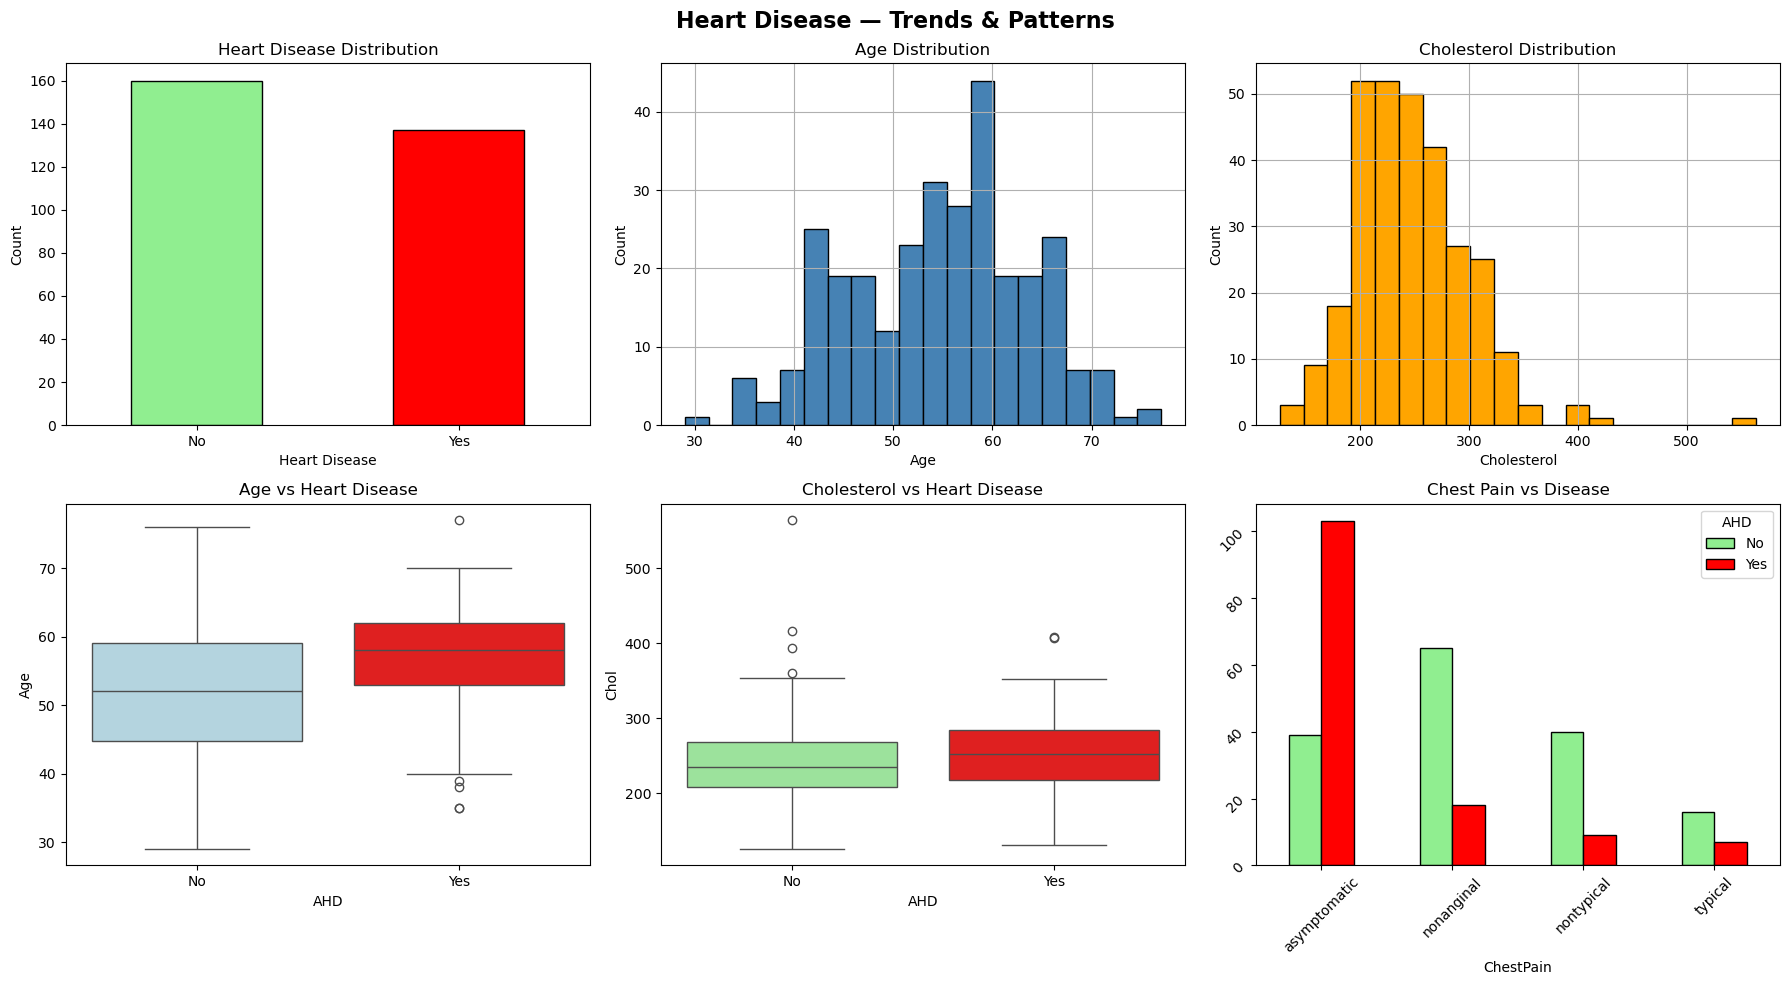

In [7]:
# Trends & Patterns :
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Heart Disease — Trends & Patterns',
             fontsize=16, fontweight='bold')

# Plot 1: Disease Distribution
df['AHD'].value_counts().plot(kind='bar',
                               ax=axes[0,0],
                               color=['lightgreen','red'],
                               edgecolor='black')
axes[0,0].set_title('Heart Disease Distribution')
axes[0,0].set_xlabel('Heart Disease')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(rotation=0)

# Plot 2: Age Distribution
df['Age'].hist(ax=axes[0,1], bins=20,
               color='steelblue',
               edgecolor='black')
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Count')

# Plot 3: Cholesterol Distribution
df['Chol'].hist(ax=axes[0,2], bins=20,
                color='orange',
                edgecolor='black')
axes[0,2].set_title('Cholesterol Distribution')
axes[0,2].set_xlabel('Cholesterol')
axes[0,2].set_ylabel('Count')

# Plot 4: Age vs Disease
sns.boxplot(x='AHD', y='Age', data=df,
            ax=axes[1,0],
            palette={'No':'lightblue','Yes':'red'})
axes[1,0].set_title('Age vs Heart Disease')

# Plot 5: Cholesterol vs Disease
sns.boxplot(x='AHD', y='Chol', data=df,
            ax=axes[1,1],
            palette={'No':'lightgreen','Yes':'red'})
axes[1,1].set_title('Cholesterol vs Heart Disease')

# Plot 6: Chest Pain vs Disease
pd.crosstab(df['ChestPain'],
            df['AHD']).plot(kind='bar',
                            ax=axes[1,2],
                            color=['lightgreen','red'],
                            edgecolor='black')
axes[1,2].set_title('Chest Pain vs Disease')
axes[1,2].tick_params(rotation=45)

plt.tight_layout()
plt.savefig('eda_patterns.png', dpi=150,
            bbox_inches='tight')
plt.show()

In [8]:
# Anomalies & Issues :
print("DATA ANOMALIES & ISSUES:")
print("="*45)

# Outliers check
Q1 = df['Chol'].quantile(0.25)
Q3 = df['Chol'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Chol'] < Q1 - 1.5*IQR) |
              (df['Chol'] > Q3 + 1.5*IQR)]
print(f"\nCholesterol Outliers: {len(outliers)}")

Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
age_outliers = df[(df['Age'] < Q1_age - 1.5*IQR_age) |
                  (df['Age'] > Q3_age + 1.5*IQR_age)]
print(f"Age Outliers: {len(age_outliers)}")

# Imbalance check
print(f"\nClass Imbalance:")
print(df['AHD'].value_counts())
print(f"Ratio: {round(df['AHD'].value_counts()[0]/df['AHD'].value_counts()[1],2)}")

DATA ANOMALIES & ISSUES:

Cholesterol Outliers: 5
Age Outliers: 0

Class Imbalance:
AHD
No     160
Yes    137
Name: count, dtype: int64
Ratio: 1.17


C:\Users\zerot\AppData\Local\Temp\ipykernel_19524\4248319156.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Ratio: {round(df['AHD'].value_counts()[0]/df['AHD'].value_counts()[1],2)}")
C:\Users\zerot\AppData\Local\Temp\ipykernel_19524\4248319156.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Ratio: {round(df['AHD'].value_counts()[0]/df['AHD'].value_counts()[1],2)}")


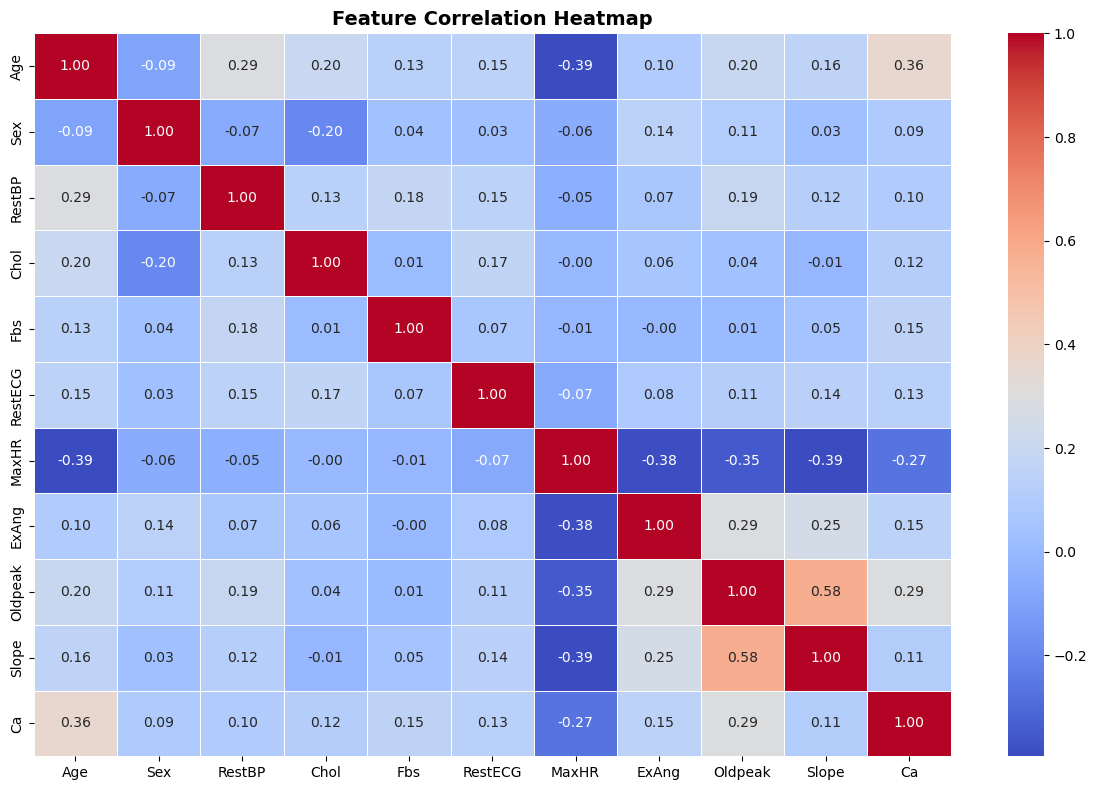

In [9]:
# Correlation & Heatmap :
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title('Feature Correlation Heatmap',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Key Insights :
print("KEY INSIGHTS FROM EDA:")
print("="*45)
print(f"1. Total Patients Analyzed: {len(df)}")
print(f"2. Heart Disease Rate: {round(df['AHD'].value_counts(normalize=True)['Yes']*100,1)}%")
print(f"3. Average Age: {round(df['Age'].mean(),1)} years")
print(f"4. Most Dangerous Chest Pain: Asymptomatic")
print(f"5. Average Cholesterol: {round(df['Chol'].mean(),1)} mg/dl")
print(f"6. Cholesterol Outliers Found: {len(outliers)}")
print(f"7. Males more affected than females")
print(f"8. Age group 50-60 most affected")
print("\nRECOMMENDATIONS:")
print("- Screen patients above 50 years")
print("- Monitor cholesterol regularly")
print("- Focus on asymptomatic chest pain cases")

KEY INSIGHTS FROM EDA:
1. Total Patients Analyzed: 297
2. Heart Disease Rate: 46.1%
3. Average Age: 54.5 years
4. Most Dangerous Chest Pain: Asymptomatic
5. Average Cholesterol: 247.4 mg/dl
6. Cholesterol Outliers Found: 5
7. Males more affected than females
8. Age group 50-60 most affected

RECOMMENDATIONS:
- Screen patients above 50 years
- Monitor cholesterol regularly
- Focus on asymptomatic chest pain cases
